# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 30     |  |
| :-------------|:-------------|
| Bruno Schouten| 6577423 |
| Damien Vogelpoel| 6438431 |
| Tijn Derks| 6530036 |
| Planning Groep:      | 11:22  |
|---|---|
| Condensator af | 1230 |
| Sensor af | 1530 |
| groep aanwezig 1| 1045-1230 |
| groep aanwezig 2| 1330-1730 |
| Pauze 1| 1230-1330 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.

<img src="IMG_2026.png" alt="schets student 1" width="400"/>

<img src="IMG_2026.png" alt="schets student 1" width="400"/>

In [17]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
#parameters
A = 0.105**2 #opppervlak in meter
d = 1.5*10**-3#afstand in meter
epsilon0 = 8.854 * 10**-12
espr_karton = 2.2 #relatieve permitiviteit karton zit tussen 2.2 en 3.8, dus gemiddeld 3
epsilon_karton = epsilon0 * espr_karton 
def vlakkeplaat(eps,A,d):
    C = eps*A/d 
    return C

C = vlakkeplaat(epsilon_karton,A,d)
print(C)

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

1.4316917999999997e-10


In [18]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [vlakkeplaat(epsilon_karton,A,d)]


print(f"Berekende capaciteit plaatcondensator groep 30 is {C[0]:.1e} pF")



Berekende capaciteit plaatcondensator groep 30 is 1.4e-10 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](IMG_2026.png)
![scope meting 2](IMG_2029.png)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit (pF)   | Berekend Voltage (V) | Gemeten Voltage (V) | Gemeten capaciteit (pF)   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 30| 140 | 0.36 | .55 |120 |

Binnen meetonzekerheid

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_2032.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die mL per uur meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_2033.png)

In [30]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

#parameters
A= 0.15*0.1#m^2
d= 3e-3#m
R = np.array([])
C = np.array([])


def vlakkeplaat(eps,A,d):
    C = eps*A/d 
    return C

print(vlakkeplaat(epsilon0, A, d))
#plt.plot(R,C)


4.427e-11


/var/folders/c2/fy7sn1ps3g15mvql7c_zl15c0000gn/T/ipykernel_69664/1142689441.py:32: RuntimeWarning: divide by zero encountered in divide
  Farad = (Voltages*C_ref)/(V_ref-Voltages)
/var/folders/c2/fy7sn1ps3g15mvql7c_zl15c0000gn/T/ipykernel_69664/1142689441.py:26: RuntimeWarning: divide by zero encountered in divide
  term2 = (width/height)*((Voltage*C_ref)/(V_ref-Voltage)) - eps_S


<function matplotlib.pyplot.show(close=None, block=None)>

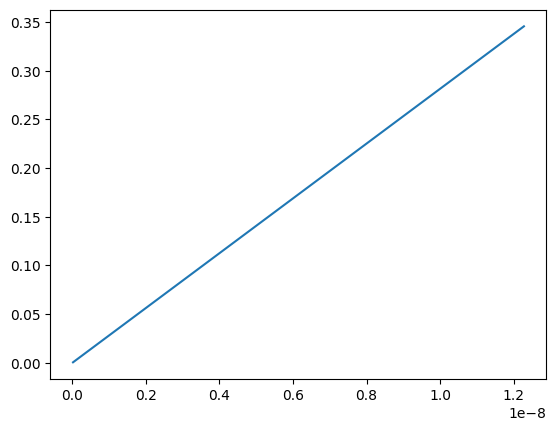

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Data
Voltage = np.zeros(5)
Time = np.zeros(5)*60 # Seconds from start



# CONSTANTS
height = 0.15       # Meter
width = 0.10        # Meter
thickness = 0.003   # Meter

Area = height*width
Volume = Area*thickness

# Epsilon values
eps0 = epsilon0
eps_S = eps0*1.1
eps_W = eps0*80.1   # Op kamertemperatuur, K=293

Max_Volume_Constant = 0.85  # Max percentage that the sponge can be saturated with water
Mass_max_water = Volume*1000*Max_Volume_Constant    # Maximum mass of water sponge can take on

# Setup values
C_ref = 100e-12 # Reference condensator in pF
V_ref = 5       # Reference input voltage in V

def VoltageMass(Voltage):   # Calculates amount of water present in the sponge
    term1 = Mass_max_water/(Max_Volume_Constant*eps_W)
    term2 = (width/height)*((Voltage*C_ref)/(V_ref-Voltage)) - eps_S

    mass = term1*term2
    return mass

def VoltageFarad(Voltages):
    Farad = (Voltages*C_ref)/(V_ref-Voltages)
    return Farad

# Dummy data
Voltages = np.linspace(1, 5, 100)

plt.figure()
plt.plot(VoltageFarad(Voltages), VoltageMass(Voltages))
plt.xlabel("Farad")
plt.ylabel("Water massa (kg)")
plt.show


# Part 2: Calculating rate of change
Top_Area = width*thickness
dt = int(1)     # Measurements

Masses = VoltageMass(Voltages)

def mm_water(d_Mass):
    return (d_Mass/Top_Area)

# Calculate mass differences between points
dMass = np.zeros(len(Masses)-1)
for index in range(len(Masses) - dt):   # Calculates difference in mass between two points
    dMass[index] = Masses[index+dt]-Masses[index]
dTimes = np.zeros(len(Time) - dt)
for index in range(len(Time) - dt):
    dTimes[index] = Time[index+dt] - Time[index]

# dTimes is in seconds, convert to hours:
dTimesH = dTimes*3600
percipitation_mm = mm_water(dMass)

# Percipitation in mm/h
water_rate = percipitation_mm/dTimesH

plt.figure()
plt.plot(Time[:-1], water_rate*1000)
plt.xlabel('Time')
plt.ylabel('Water mm/hour')




## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| ? |? |
| gemiddelde capaciteit| ? |? |
| maximale capaciteit| ? |? |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](tudelftLogo.png)
![meting 2](tudelftLogo.png)

## Opdracht 7: Plot de kalibratiegrafiek.

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1
* verbetering 2

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

Vul hier de conclusie in

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.